<a href="https://colab.research.google.com/github/jisjeeson/HOUSE_PRICING_CASESTUDY_ICT/blob/main/case_study_jis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
import numpy as np
import pandas as pd
import seaborn as sns

In [138]:
df=pd.read_csv("/content/House_Pricing.csv")
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [140]:
df = df.drop(columns=["ID"])

In [141]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489
Condition of the House,0


In [142]:
columns_to_drop = [
    "Sale Price",
    "No of Bathrooms",
    "Flat Area (in Sqft)",
    "Lot Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Zipcode",
    "Latitude",
    "Longitude",
    "Living Area after Renovation (in Sqft)"
]

df = df.dropna(subset=columns_to_drop)

In [143]:
df = df.drop(columns=["No of Times Visited"])

In [144]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [145]:
df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.158000e+04,21580.000000,21580.000000,21580.000000,2.158000e+04,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000
mean,5.401245e+05,3.371223,2.114597,2079.896803,1.511585e+04,1.494231,7.623262,1788.456812,291.439991,47.003290,84.254588,98077.925394,47.559986,-122.213850,1986.478777,12775.341983
std,3.674325e+05,0.930086,0.770140,918.245846,4.144975e+04,0.539897,1.105684,828.057019,442.383441,29.366011,401.344975,53.513818,0.138572,0.140849,685.499001,27322.722954
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.210202e+05,3.000000,1.750000,1430.000000,5.042750e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470775,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571700,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.069050e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.677900,-122.125000,2360.000000,10087.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [146]:
df["Date House was Sold"] = pd.to_datetime(df["Date House was Sold"])

sale_year = df["Date House was Sold"].dt.year

df["Renovated_Last_25_Years"] = (
    (df["Renovated Year"] > 0) &
    ((sale_year - df["Renovated Year"]) <= 25)
).astype(int)

In [147]:


df["House_Age"] = 2021 - df["Date House was Sold"].dt.year

In [148]:
df = df.drop(columns=["Date House was Sold"])

In [149]:
df = df.drop(columns=["Renovated Year"])

In [150]:
df.head(2)

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Renovated_Last_25_Years,House_Age
0,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,98178.0,47.5112,-122.257,1340.0,5650,0,4
1,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,98125.0,47.7210,-122.319,1690.0,7639,0,4


In [151]:
df["Renovated_Last_25_Years"].value_counts()
df["Renovated_Last_25_Years"].value_counts(normalize=True) * 100

,proportion
Renovated_Last_25_Years,
0,97.224282
1,2.775718


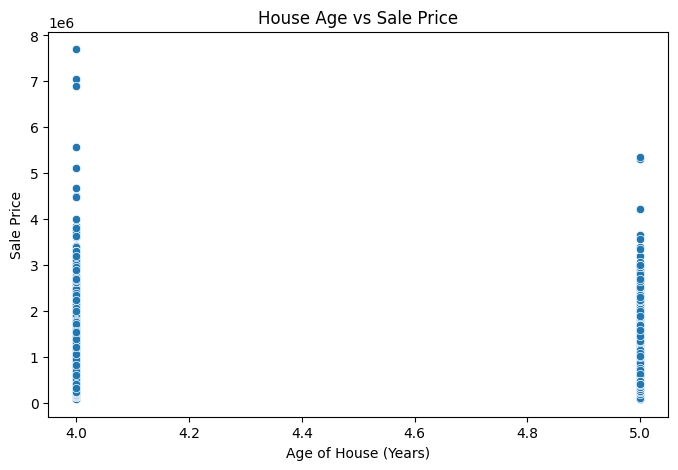

In [176]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="House_Age",
    y="Sale Price",
    data=df
)

plt.xlabel("Age of House (Years)")
plt.ylabel("Sale Price")
plt.title("House Age vs Sale Price")

plt.show()

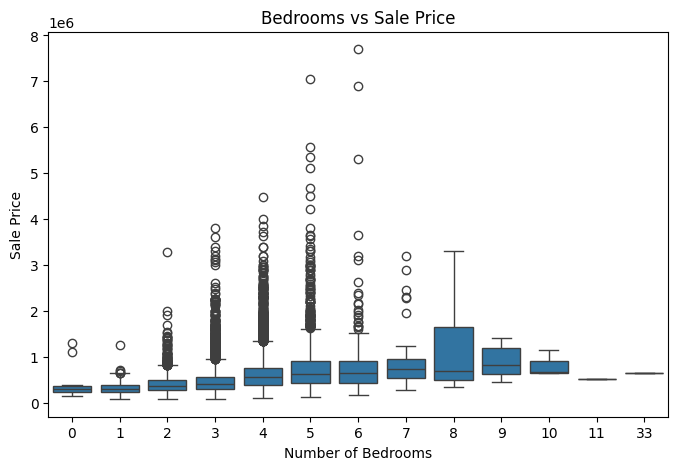

In [153]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="No of Bedrooms",
    y="Sale Price",
    data=df
)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price")
plt.title("Bedrooms vs Sale Price")

plt.show()

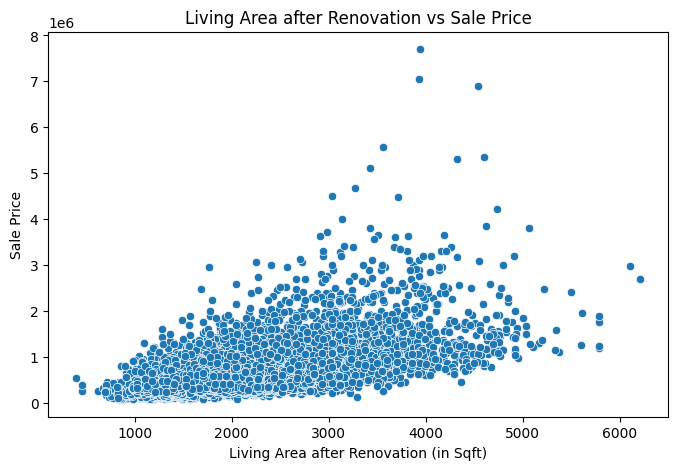

In [155]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Living Area after Renovation (in Sqft)",
    y="Sale Price",
    data=df
)

plt.xlabel("Living Area after Renovation (in Sqft)")
plt.ylabel("Sale Price")
plt.title("Living Area after Renovation vs Sale Price")

plt.show()

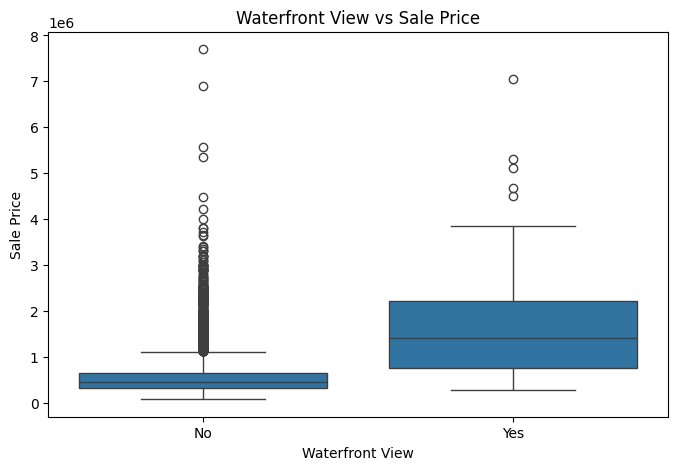

In [157]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Waterfront View",
    y="Sale Price",
    data=df
)

plt.xlabel("Waterfront View")
plt.ylabel("Sale Price")
plt.title("Waterfront View vs Sale Price")

plt.show()

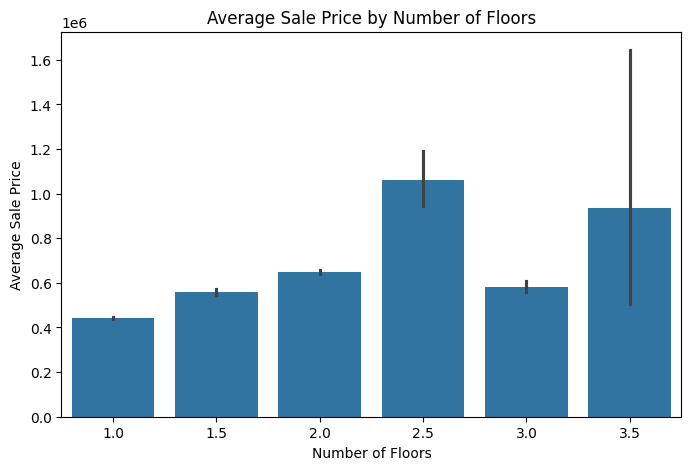

In [158]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="No of Floors",
    y="Sale Price",
    data=df,
    estimator="mean"
)

plt.xlabel("Number of Floors")
plt.ylabel("Average Sale Price")
plt.title("Average Sale Price by Number of Floors")

plt.show()

In [159]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Waterfront View
['No' 'Yes']

Condition of the House
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [160]:
from sklearn.preprocessing import OrdinalEncoder

oe_condition = OrdinalEncoder(
    categories=[["Bad", "Fair", "Okay", "Good", "Excellent"]]
)

df[["Condition of the House"]] = oe_condition.fit_transform(
    df[["Condition of the House"]]
)

In [161]:
df["Condition of the House"].value_counts()

,count
Condition of the House,
1.0,14010
3.0,5670
4.0,1698
2.0,172
0.0,30


In [162]:
from sklearn.preprocessing import LabelEncoder

le_waterfront = LabelEncoder()

df["Waterfront View"] = le_waterfront.fit_transform(
    df["Waterfront View"]
)

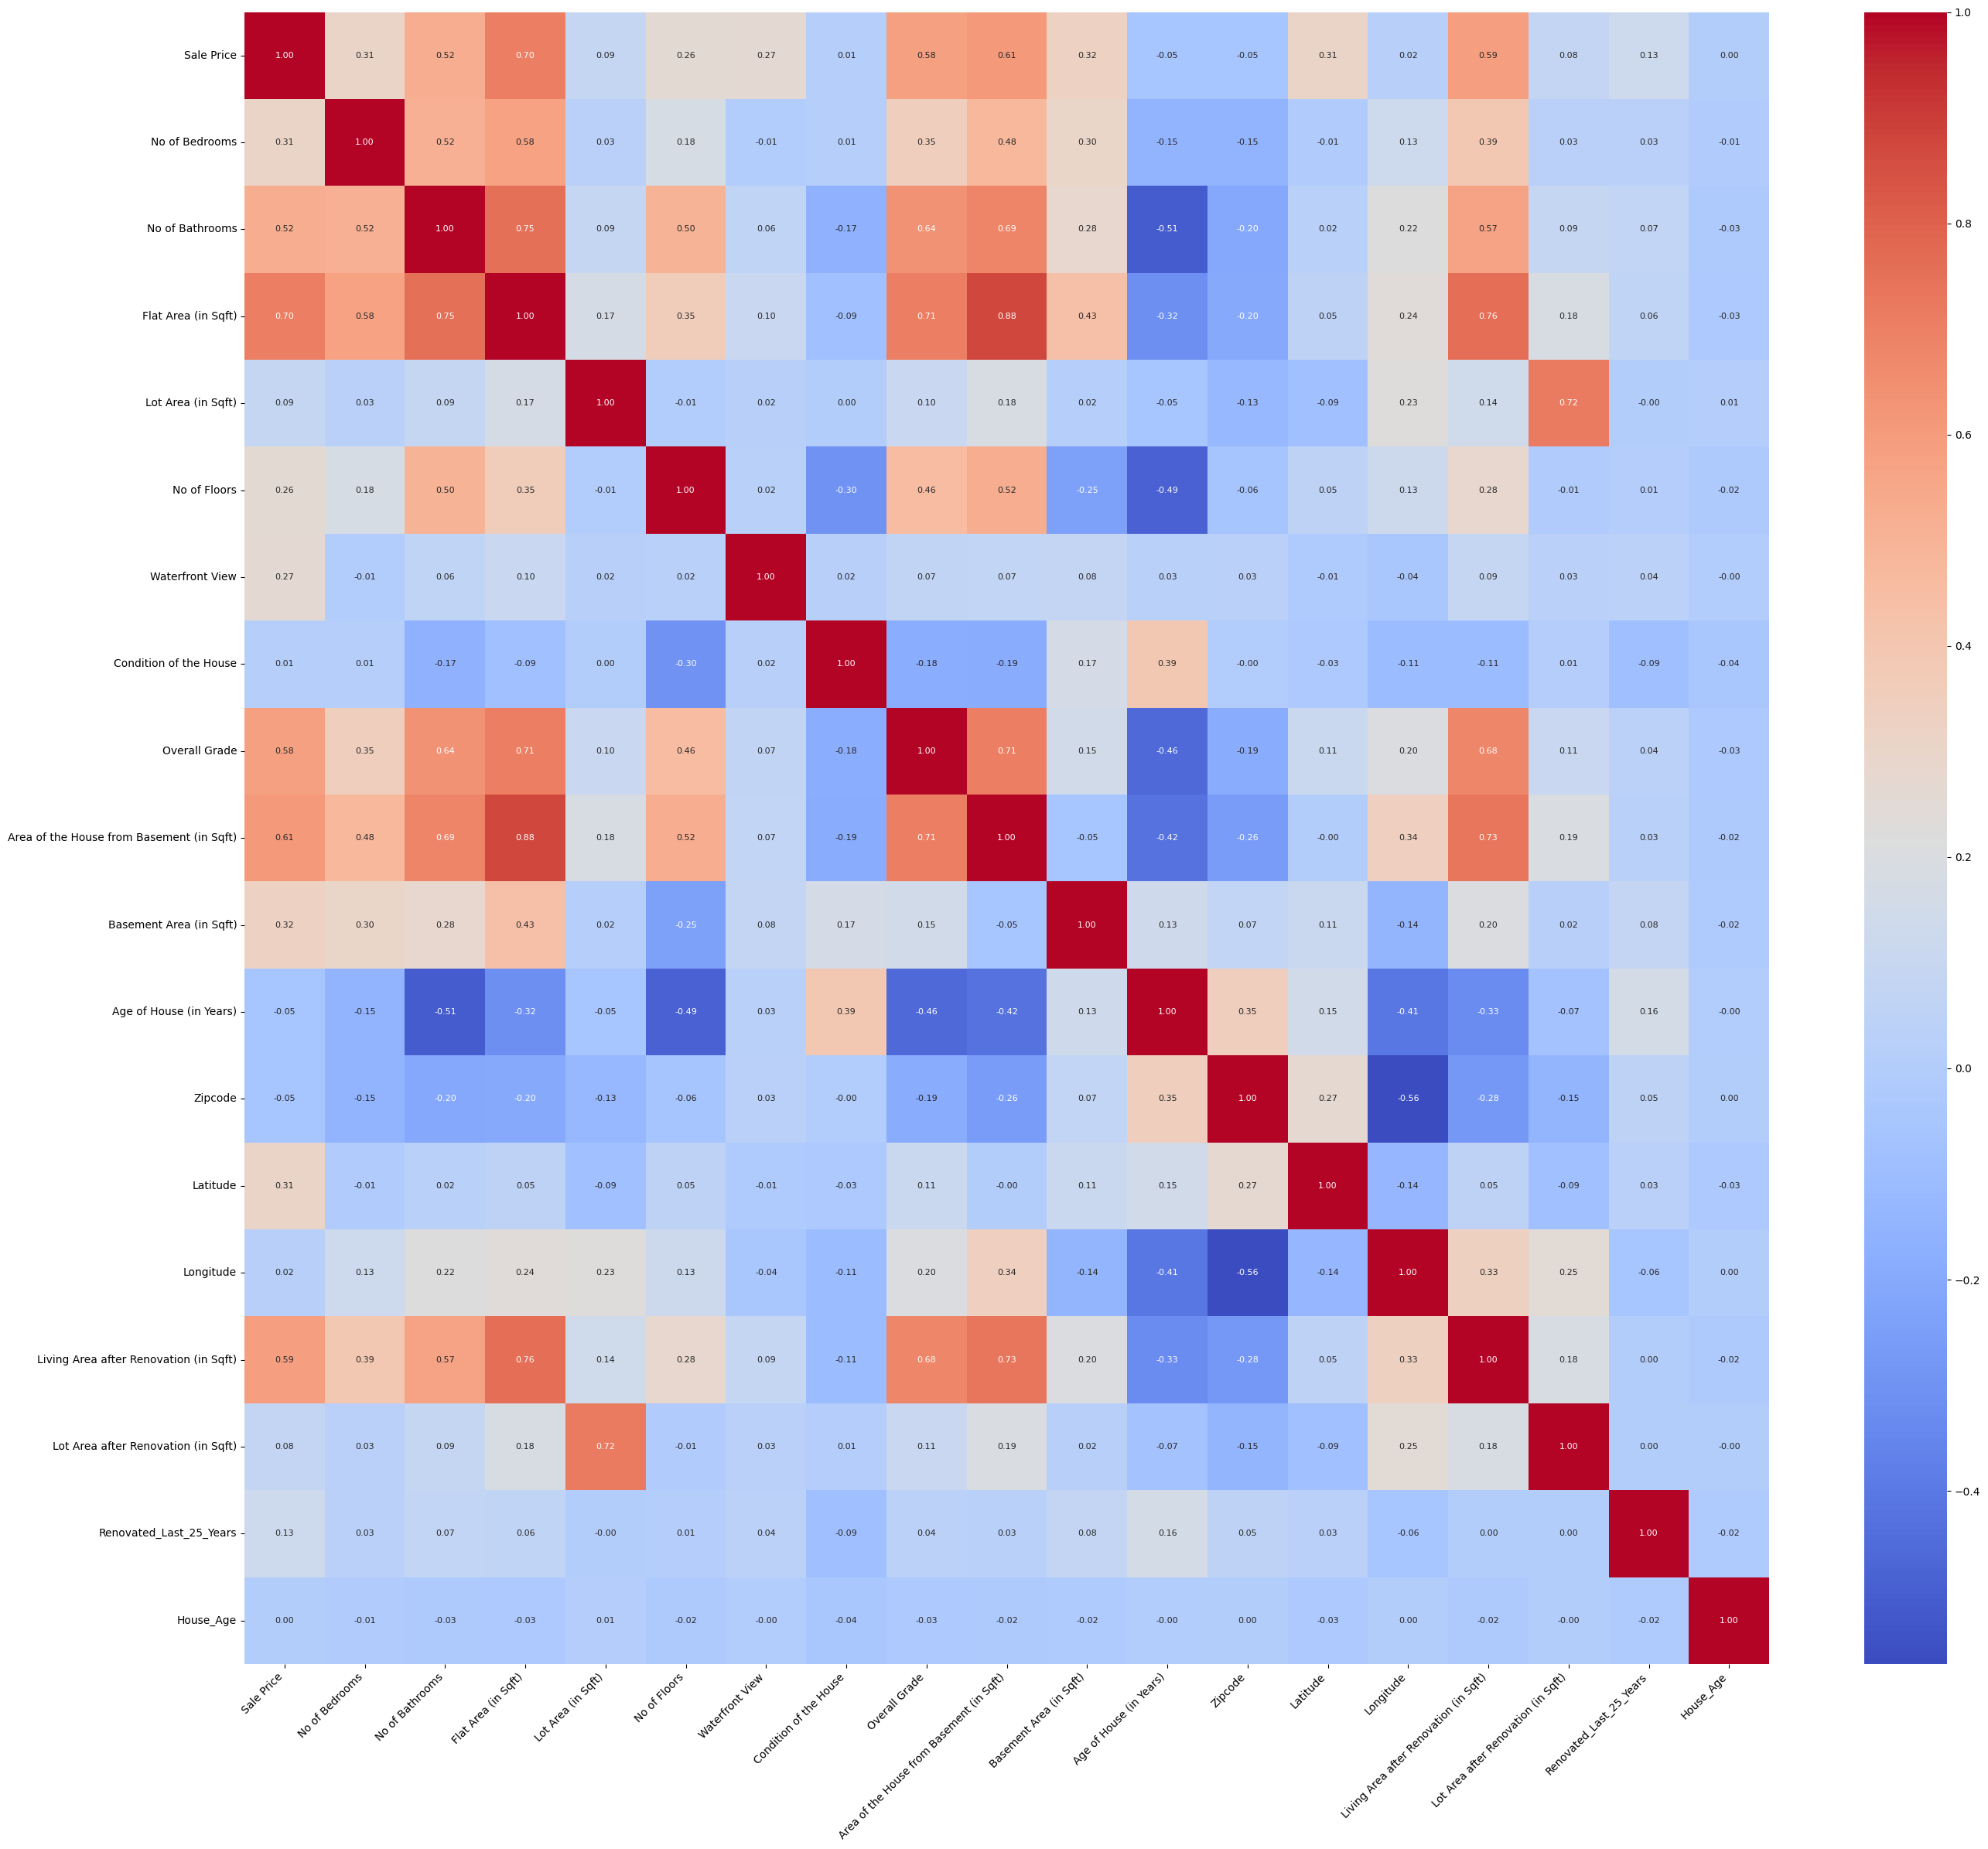

In [163]:
plt.figure(figsize=(28, 24))

corr_result = df.corr(numeric_only=True)

sns.heatmap(
    corr_result,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [164]:
saleprice_corr = corr_result["Sale Price"]

selected_corr = saleprice_corr[
    saleprice_corr.abs() >= 0.40
].sort_values(ascending=False)

selected_corr

,Sale Price
Sale Price,1.000000
Flat Area (in Sqft),0.701904
Area of the House from Basement (in Sqft),0.605464
Living Area after Renovation (in Sqft),0.585345
Overall Grade,0.580509
No of Bathrooms,0.524909


In [165]:
selected_features = [
    "Flat Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "No of Bathrooms"
]

In [166]:
selected_features = [
    "Flat Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "No of Bathrooms"
]

for column in selected_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Outliers:", len(outliers))
    print("Outlier %:", round(len(outliers) / len(df) * 100, 2))
    print()

Flat Area (in Sqft)
Lower Bound: -250.0
Upper Bound: 4230.0
Outliers: 571
Outlier %: 2.65

Area of the House from Basement (in Sqft)
Lower Bound: -340.0
Upper Bound: 3740.0
Outliers: 610
Outlier %: 2.83

Living Area after Renovation (in Sqft)
Lower Bound: 185.0
Upper Bound: 3665.0
Outliers: 544
Outlier %: 2.52

No of Bathrooms
Lower Bound: 0.625
Upper Bound: 3.625
Outliers: 569
Outlier %: 2.64



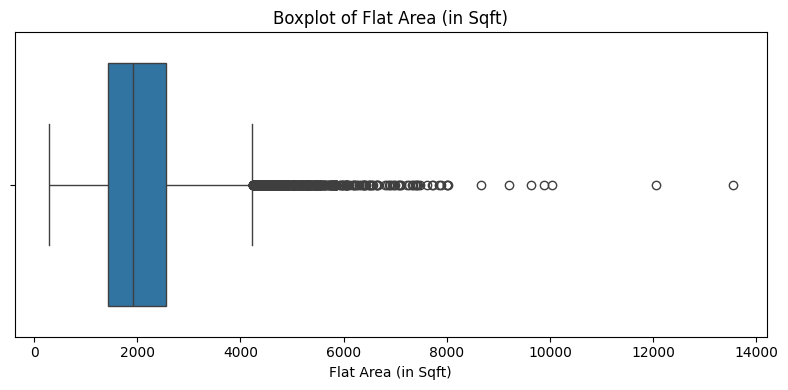

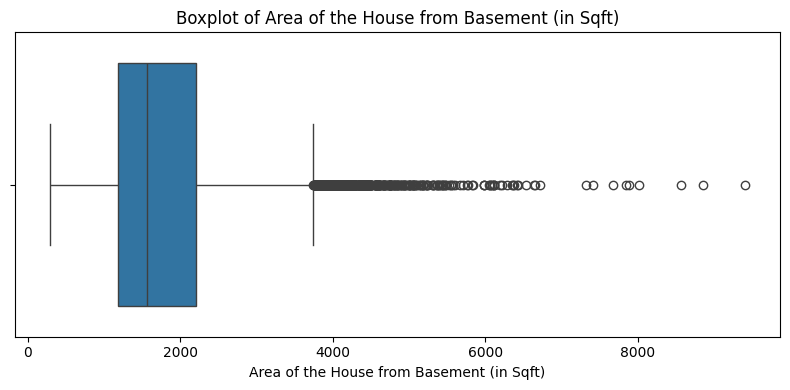

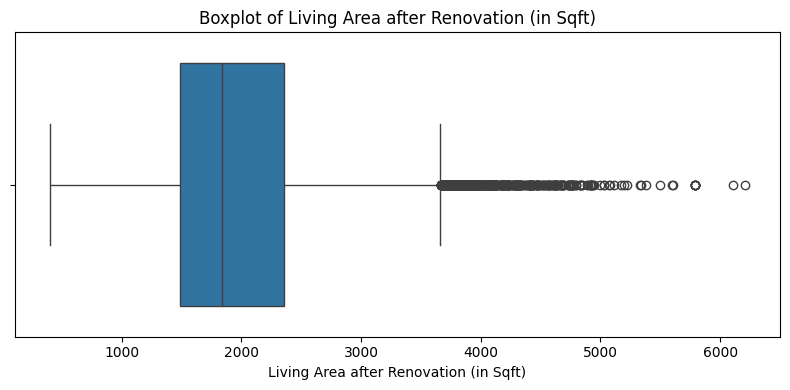

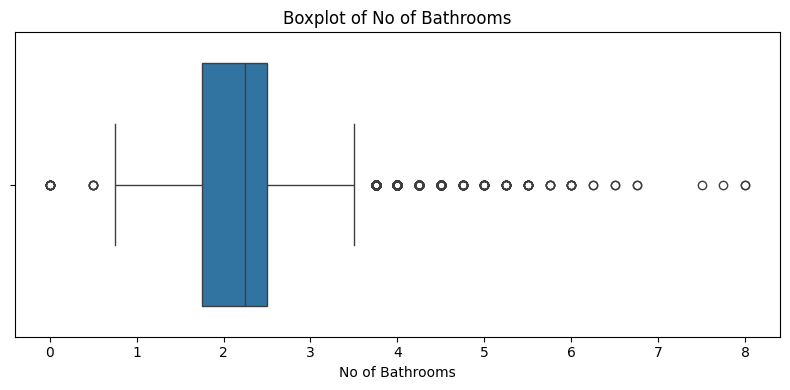

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = [
    "Flat Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "No of Bathrooms"
]

for column in selected_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [168]:
selected_features = [
    "Flat Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "No of Bathrooms"
]

for column in selected_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

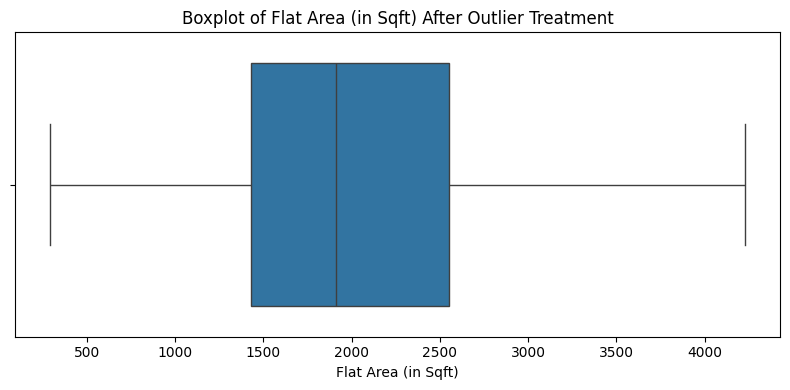

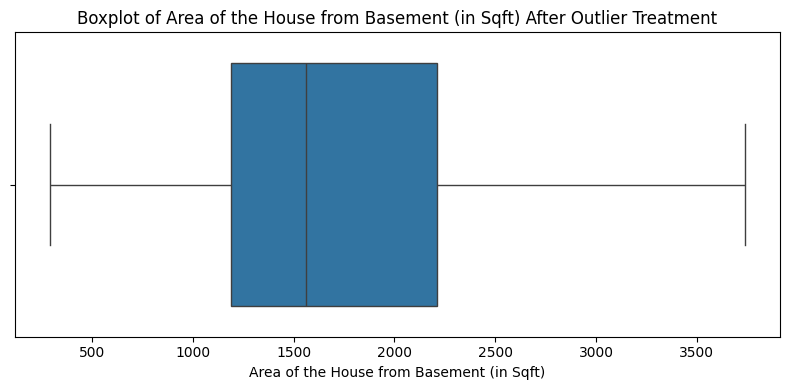

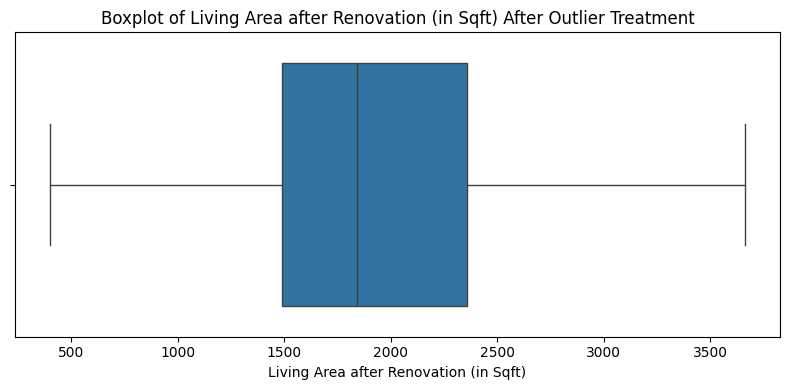

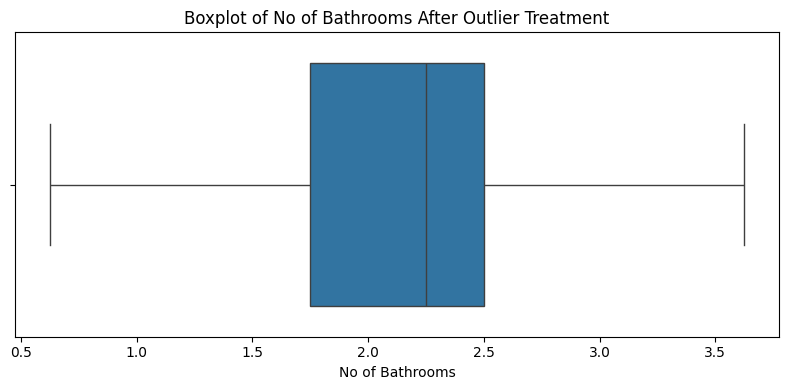

In [169]:
for column in selected_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column} After Outlier Treatment")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [170]:
selected_features = [
    "Flat Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "No of Bathrooms"
]

X = df[selected_features]
y= df["Sale Price"]

In [171]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21580, 4)
y shape: (21580,)


In [172]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17264, 4)
X_test: (4316, 4)
y_train: (17264,)
y_test: (4316,)


In [173]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)